In [42]:
import os
import re
import numpy as np
import pickle
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from utils import find_recipe_in_batch, plot_recipe
from calculate_sds import obj_inclusion_exclusion, find_recipe_repetitions
sampling_batch_size = 10000
gt_color = np.array((59, 124, 243))/256
pr_color = np.array((117, 251, 76))/256

In [35]:
data = pd.read_excel('data/survey/PALATE.xlsx')
i1 = 5 # where the data starts in the excel file
n = len(data) - i1 # should be 101

In [84]:
data

,Unnamed: 0,Unnamed: 1,Participant,Participant.1,Participant.2,Participant.3,Participant.4,Participant.5,Participant.6,Unnamed: 9,...,Nutritious.2,Nutritious.3,Nutritious.4,Nutritious.5,Nutritious.6,Nutritious.7,Nutritious.8,Nutritious.9,Nutritious.10,Nutritious.11
0,NaN,NaN,Age,Gender,Education,Dietary Preference,Burger Frequency,Priorities,Grocery Store Habilts,NaN,...,Likert,Intensity,Intensity,Intensity,Intensity,Intensity,Cata,Cata,Qualitative,Qualitative
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Texture,Softness,Hardness,Fattiness,Meatiness,Fibrosity,CFlavor,CTexture,Likes,Dislikes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Respondent,NaN,[QUESTION_TYPE: Demographic]\n[MODALITY: Age]\...,[QUESTION_TYPE: Demographic]\n[MODALITY: Gende...,[QUESTION_TYPE: Demographic]\n[MODALITY: Educa...,[QUESTION_TYPE: Demographic]\n[MODALITY: Dieta...,[QUESTION_TYPE: Demographic]\n[MODALITY: Burge...,[QUESTION_TYPE: Demographic]\n[MODALITY: Prior...,[QUESTION_TYPE: Demographic]\n[MODALITY: Groce...,NaN,...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...,[RELATED_PRODUCT: Nutritious Burger]\n[QUESTIO...
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,19253938570,NaN,18-25,Male,High School,"Flexitarian (i.e., eats meat occasionally)",2-3 times a week,Health,*Natural Grocers* (ex: Whole Foods),NaN,...,1,1,1,1,1,3,"Earthy / Soil, Bland","Crumbly / Grainy, Soft / Mushy, Brittle",It‚Äôs not a burger.,Not a burger
102,19254879398,NaN,36-45,Female,Bachelor's Degree,"Flexitarian (i.e., eats meat occasionally)",Once every 1-2 months,"Taste, Health, Price, Animal Welfare, Convenie...","*Conventional Grocers* (ex: Stop & Shop, Safew...",NaN,...,5,4,1,1,1,1,"Earthy / Soil, Savory","Dry, Soft / Mushy","Tastes healthy, and I like beans","That the texture is a little soft , and it‚Äôs..."
103,19254993999,NaN,18-25,Male,Some College,"Omnivore (i.e., eats meat regularly)",2-3 times a week,Health,"*Grocery Delivery Services* (ex: Instacart, Am...",NaN,...,5,3,1,1,1,4,Savory,"Soft / Mushy, Fibrous / Stringy",I was pleasantly surprised by the Beans. The c...,Presentation it is hard for someone to see bea...
104,19257261130,NaN,18-25,Male,Some College,"Omnivore (i.e., eats meat regularly)",Once a week,Price,*Natural Grocers* (ex: Whole Foods),NaN,...,4,2,3,4,2,1,Off-flavor,"Dry, Crumbly / Grainy",taste was okay,undercooked


In [97]:
def mybarplots(cats, counts, ylabel):
    cats = [cat.lower() for cat in cats]
    
    fig, ax = plt.subplots(figsize=(len(cats)*0.5,1.5))
    bars = ax.bar(cats, counts, color=gt_color, edgecolor='black')
    labels = [str(int(np.round(count))) + '%' for count in counts]
    ax.bar_label(bars, labels=labels)

    ax.set(ylabel=ylabel, yticks=[])
    ax.tick_params(axis='x', labelrotation=90)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Age

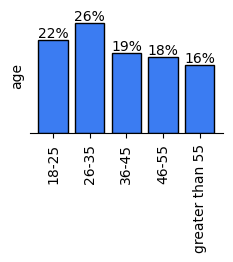

In [98]:
cats, counts = np.unique(data['Participant'][i1:], return_counts=True)
counts = counts/n*100
# cats = np.insert(cats, 0, 'Less than 18')
# counts = np.insert(counts, 0, 0)
mybarplots(cats, counts, ylabel='age')

# Gender

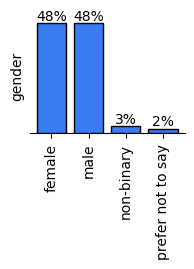

In [99]:
cats, counts = np.unique(data['Participant.1'][i1:], return_counts=True)
counts = counts/n*100
mybarplots(cats, counts, ylabel='gender')

# Education

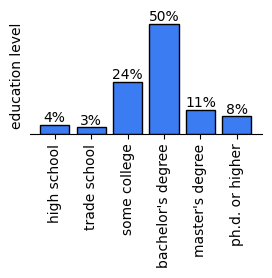

In [100]:
cats, counts = np.unique(data['Participant.2'][i1:], return_counts=True)
counts = counts/n*100
preferred = ['High School', 'Trade School', 'Some College', 'Bachelor\'s Degree', 'Master\'s Degree', 'Ph.D. or higher']
order = {name: i for i, name in enumerate(preferred)}
idx = np.argsort([order[c] for c in cats])
cats, counts = cats[idx], counts[idx]
mybarplots(cats, counts, ylabel='education level')

# Burger consumption frequency

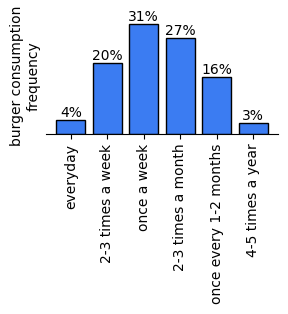

In [101]:
cats, counts = np.unique(data['Participant.4'][i1:], return_counts=True)
counts = counts/n*100
preferred = ['Everyday', '2-3 times a week', 'Once a week', '2-3 times a month', 'Once every 1-2 months', '4-5 times a year']
order = {name: i for i, name in enumerate(preferred)}
idx = np.argsort([order[c] for c in cats])
cats, counts = cats[idx], counts[idx]
mybarplots(cats, counts, ylabel='burger consumption\nfrequency')

# Dietary Preference

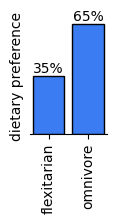

In [106]:
cats, counts = np.unique(data['Participant.3'][i1:], return_counts=True)
counts = counts/n*100
# preferred = ['Everyday', '2-3 times a week', 'Once a week', '2-3 times a month', 'Once every 1-2 months', '4-5 times a year']
# order = {name: i for i, name in enumerate(preferred)}
# idx = np.argsort([order[c] for c in cats])
# cats, counts = cats[idx], counts[idx]
cats[np.where(cats=='Flexitarian (i.e., eats meat occasionally)')] = 'flexitarian'
cats[np.where(cats=='Omnivore (i.e., eats meat regularly)')] = 'omnivore'
mybarplots(cats, counts, ylabel='dietary preference')

# Grocery store habits

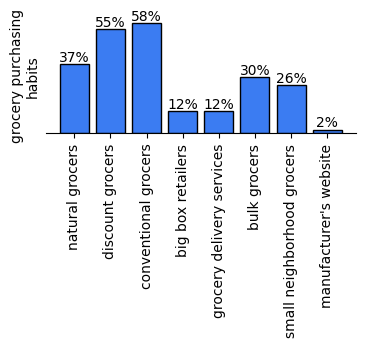

In [113]:
cats = ['Natural Grocers', 'Discount Grocers', 'Conventional Grocers', 'Big Box Retailers', 'Grocery Delivery Services', 'Bulk Grocers', 'Small Neighborhood Grocers', 'Manufacturer\'s website']
counts = [36.6, 55.4, 58.4, 11.9, 11.9, 29.7, 25.7, 2.0]
mybarplots(cats, counts, ylabel='grocery purchasing\nhabits')

# Priorities

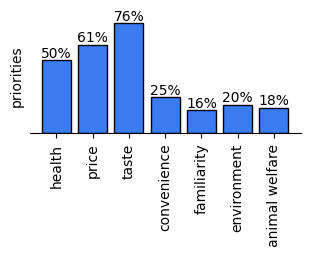

In [115]:
cats = ['Health', 'Price', 'Taste', 'Convenience', 'Familiarity', 'Environment', 'Animal welfare']
counts = [50.5, 61.4, 76.2, 24.8, 15.8, 19.8, 17.8]
mybarplots(cats, counts, ylabel='priorities')